<div align='center'>
    <h1>Responsi Praktikum Dasar Kecerdasan Artifisial</h1>
</div>

Nama: 'Aarif Rahmaan Jalaluddin Faqiih

NIM: 103112430182

# **Studi Kasus 1** (40 Point)

**Deskripsi Masalah:** Seorang kurir logistik harus menempuh perjalanan dari Kota A (Start) ke Kota G (Goal). Terdapat beberapa jalur dengan jarak aktual (bobot edge) dan estimasi jarak udara (heuristik) ke Kota G sebagai berikut:

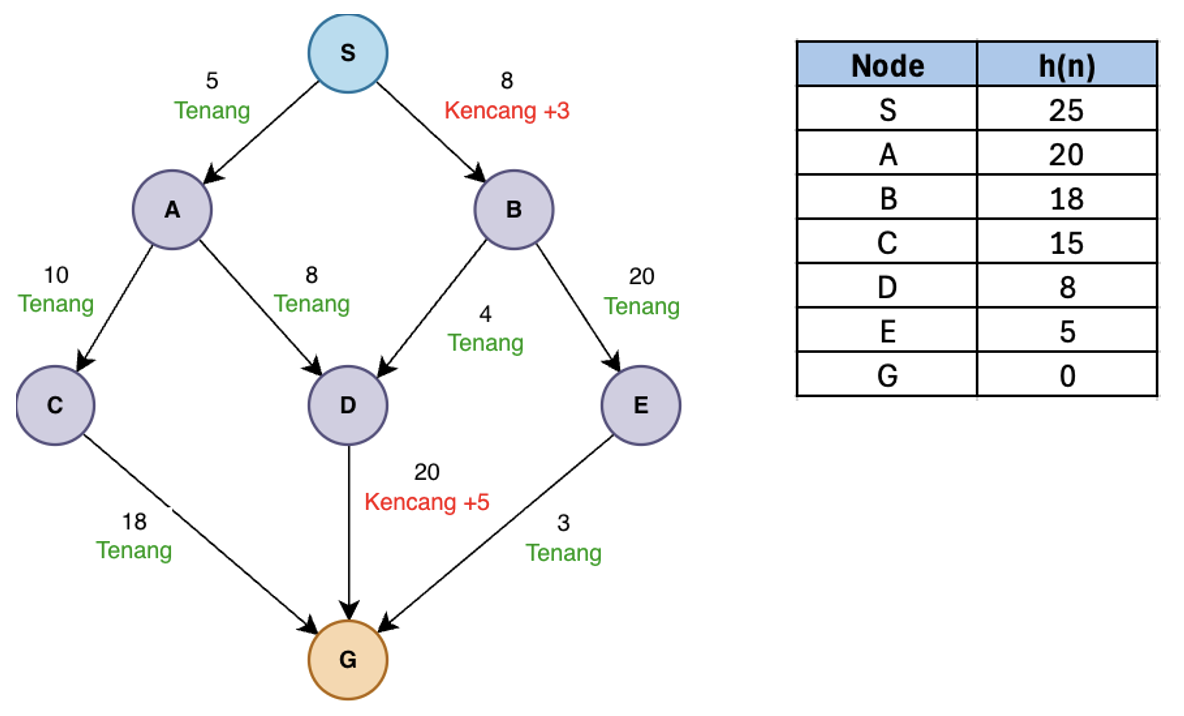

**Tugas Praktikan**:
1.   Buatlah struktur graf berarah menggunakan **NetworkX**. Sertakan bobot total (Jarak + Hambatan Angin) pada setiap edge.
2.   Gunakan algoritma A* untuk menemukan jalur dengan total biaya terkecil. Tampilkan urutan node yang dilewati dan total biayanya.
3. Analisis: Jika faktor angin tiba-tiba hilang (semua tambahan bobot menjadi 0), apakah jalur optimal drone akan berubah? Buktikan dengan menjalankan kembali pencarian A* dan bandingkan hasilnya.

In [1]:
# Import library terlebih dahulu
import networkx as nx

In [2]:
# Definisikan estimasi jarak udara (Heuristik) ke Goal (G)
heuristics = {
    'S': 25,
    'A': 20,
    'B': 18,
    'C': 15,
    'D': 8,
    'E': 5,
    'G': 0
}

In [3]:
def h_func(u, v):
    return heuristics[u]

### Dengan Faktor Angin (Kencang)

In [4]:
G_wind = nx.DiGraph()

# Menambahkan edge beserta total bobot (Jarak Aktual + Hambatan Angin)
G_wind.add_edge('S', 'A', weight=5)   # Tenang (5 + 0)
G_wind.add_edge('S', 'B', weight=11)  # Kencang +3 (8 + 3)
G_wind.add_edge('A', 'C', weight=10)  # Tenang
G_wind.add_edge('A', 'D', weight=8)   # Tenang
G_wind.add_edge('B', 'D', weight=4)   # Tenang
G_wind.add_edge('B', 'E', weight=20)  # Tenang
G_wind.add_edge('C', 'G', weight=18)  # Tenang
G_wind.add_edge('D', 'G', weight=25)  # Kencang +5 (20 + 5)
G_wind.add_edge('E', 'G', weight=3)   # Tenang

In [5]:
# Menghitung jalur terpendek dengan A*
path_wind = nx.astar_path(G_wind, 'S', 'G', heuristic=h_func)
cost_wind = nx.astar_path_length(G_wind, 'S', 'G', heuristic=h_func)

### Tanpa Faktor Angin

In [6]:
G_no_wind = nx.DiGraph()

# Menambahkan edge menggunakan bobot dasar asli (kondisi tenang semua)
G_no_wind.add_edge('S', 'A', weight=5)
G_no_wind.add_edge('S', 'B', weight=8)   # Kembali ke bobot dasar 8
G_no_wind.add_edge('A', 'C', weight=10)
G_no_wind.add_edge('A', 'D', weight=8)
G_no_wind.add_edge('B', 'D', weight=4)
G_no_wind.add_edge('B', 'E', weight=20)
G_no_wind.add_edge('C', 'G', weight=18)
G_no_wind.add_edge('D', 'G', weight=20)  # Kembali ke bobot dasar 20
G_no_wind.add_edge('E', 'G', weight=3)

In [7]:
# Menghitung jalur terpendek dengan A*
path_no_wind = nx.astar_path(G_no_wind, 'S', 'G', heuristic=h_func)
cost_no_wind = nx.astar_path_length(G_no_wind, 'S', 'G', heuristic=h_func)

### Hasil

In [8]:
print("=========== HASIL EKSEKUSI A* ===========")
print("1. KONDISI DENGAN FAKTOR ANGIN:")
print(f"   * Urutan Jalur : {' -> '.join(path_wind)}")
print(f"   * Total Biaya  : {cost_wind}")
print("-" * 41)
print("2. KONDISI TANPA FAKTOR ANGIN:")
print(f"   * Urutan Jalur : {' -> '.join(path_no_wind)}")
print(f"   * Total Biaya  : {cost_no_wind}")
print("=========================================")

=========== HASIL EKSEKUSI A* ===========
1. KONDISI DENGAN FAKTOR ANGIN:
   * Urutan Jalur : S -> A -> C -> G
   * Total Biaya  : 33
-----------------------------------------
2. KONDISI TANPA FAKTOR ANGIN:
   * Urutan Jalur : S -> B -> D -> G
   * Total Biaya  : 32


Analisis:

Di awal, saat angin masih kencang, bobot dari node S ke B dan node D ke G mendapat tambahan biaya. Makanya, algoritma A* mencari jalur alternatif agar biayanya sekecil mungkin, dan terpilihlah rute S - A - C - G dengan total biaya 33.

Tapi setelah faktor angin kita nol-kan, jalur asli yang melewati B dan D kembali normal. Karena rute S - B - D - G pada dasarnya punya biaya yang lebih kecil yaitu 32, algoritma A * langsung beralih ke jalur ini. Maka dari itu, perhitungan heuristik pada A star sangat bergantung pada bobot tiap edge. Jika ada sedikit saja perubahan pada bobot, hasil rute yang dipilih juga pasti ikut menyesuaikan demi mencari total biaya terkecil.

# **Studi Kasus 2** (60 Point)

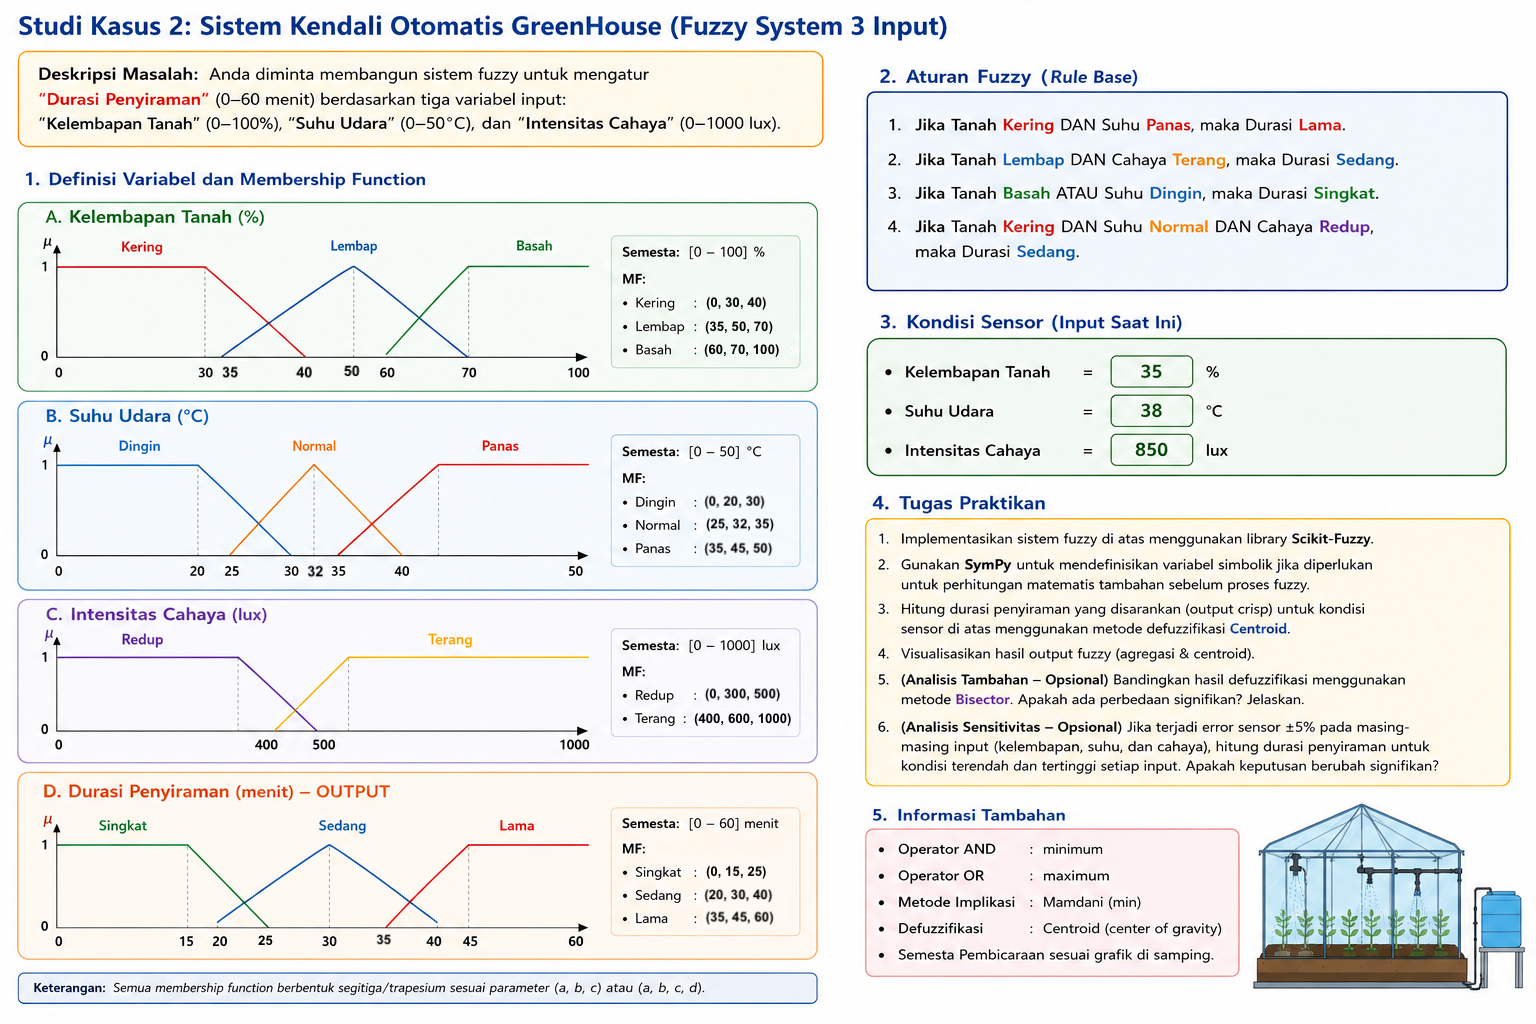

In [9]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

!pip install scikit-fuzzy
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [10]:
# Mendefinisikan simbol matematika
k_sym, s_sym, c_sym, d_sym = sp.symbols('Kelembapan Suhu Cahaya Durasi')
print(f"[SymPy] Variabel simbolik berhasil dibuat: {k_sym}, {s_sym}, {c_sym}, {d_sym}")

[SymPy] Variabel simbolik berhasil dibuat: Kelembapan, Suhu, Cahaya, Durasi


### Implementasi Sistem Fuzzy dengan Scikit-Fuzzy

In [11]:
# Definisi Semesta Pembicaraan (Universe)
kelembapan = ctrl.Antecedent(np.arange(0, 101, 1), 'kelembapan')
suhu = ctrl.Antecedent(np.arange(0, 51, 1), 'suhu')
cahaya = ctrl.Antecedent(np.arange(0, 1001, 1), 'cahaya')
durasi = ctrl.Consequent(np.arange(0, 61, 1), 'durasi')

In [12]:
# Definisi Membership Function (MF)

kelembapan['kering'] = fuzz.trapmf(kelembapan.universe, [0, 0, 30, 40])
kelembapan['lembap'] = fuzz.trimf(kelembapan.universe, [35, 50, 70])
kelembapan['basah'] = fuzz.trapmf(kelembapan.universe, [60, 70, 100, 100])

suhu['dingin'] = fuzz.trapmf(suhu.universe, [0, 0, 20, 30])
suhu['normal'] = fuzz.trimf(suhu.universe, [25, 32, 35])
suhu['panas'] = fuzz.trapmf(suhu.universe, [35, 45, 50, 50])

cahaya['redup'] = fuzz.trapmf(cahaya.universe, [0, 0, 300, 500])
cahaya['terang'] = fuzz.trapmf(cahaya.universe, [400, 600, 1000, 1000])

durasi['singkat'] = fuzz.trapmf(durasi.universe, [0, 0, 15, 25])
durasi['sedang'] = fuzz.trimf(durasi.universe, [20, 30, 40])
durasi['lama'] = fuzz.trapmf(durasi.universe, [35, 45, 60, 60])

In [13]:
# Pembuatan Aturan Fuzzy (Rule Base)

rule1 = ctrl.Rule(kelembapan['kering'] & suhu['panas'], durasi['lama'])
rule2 = ctrl.Rule(kelembapan['lembap'] & cahaya['terang'], durasi['sedang'])
rule3 = ctrl.Rule(kelembapan['basah'] | suhu['dingin'], durasi['singkat'])
rule4 = ctrl.Rule(kelembapan['kering'] & suhu['normal'] & cahaya['redup'], durasi['sedang'])

In [14]:
# Membangun Sistem Kontrol dan Simulasi

greenhouse_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4])
simulasi = ctrl.ControlSystemSimulation(greenhouse_ctrl)

### Uji Kondisi Sensor Saat Ini

In [15]:
simulasi.input['kelembapan'] = 35
simulasi.input['suhu'] = 38
simulasi.input['cahaya'] = 850

In [16]:
simulasi.compute()
durasi_centroid = simulasi.output['durasi']

In [17]:
print("=================== HASIL DEFUZZIFIKASI ===================")
print(f"Kondisi Sensor -> Kelembapan: 35%, Suhu: 38 derajat C, Cahaya: 850 lux")
print(f"Rekomendasi Durasi Penyiraman (Centroid): {durasi_centroid:.2f} menit")
print("===========================================================")

=================== HASIL DEFUZZIFIKASI ===================
Kondisi Sensor -> Kelembapan: 35%, Suhu: 38 derajat C, Cahaya: 850 lux
Rekomendasi Durasi Penyiraman (Centroid): 48.23 menit


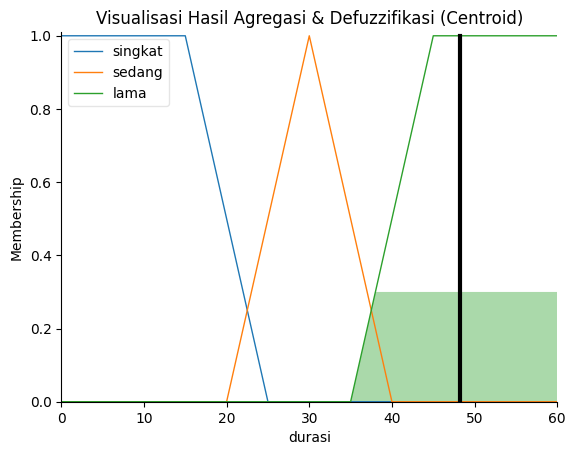

In [18]:
durasi.view(sim=simulasi)
plt.title("Visualisasi Hasil Agregasi & Defuzzifikasi (Centroid)")
plt.show()

### Analisis Metode Defuzzifikasi Bisector

In [19]:
# Mengubah metode defuzzifikasi dari centroid (default) ke bisector
durasi.defuzzify_method = 'bisector'

simulasi.compute()
durasi_bisector = simulasi.output['durasi']

In [20]:
print(f"Rekomendasi Durasi Penyiraman (Bisector): {durasi_bisector:.2f} menit")

durasi.defuzzify_method = 'centroid'

Rekomendasi Durasi Penyiraman (Bisector): 48.23 menit


### Analisis Sensitivitas Error Sensor -+ 5%

In [21]:
# Skenario Terendah (-5%)
simulasi.input['kelembapan'] = 35 - 1.75
simulasi.input['suhu'] = 38 - 1.9
simulasi.input['cahaya'] = 850 - 42.5
simulasi.compute()
output_min = simulasi.output['durasi']

In [22]:
# Skenario Tertinggi (+5%)
simulasi.input['kelembapan'] = 35 + 1.75
simulasi.input['suhu'] = 38 + 1.9
simulasi.input['cahaya'] = 850 + 42.5
simulasi.compute()
output_max = simulasi.output['durasi']

In [23]:
print(f"Output skenario terendah (-5%) : {output_min:.2f} menit")
print(f"Output skenario tertinggi (+5%): {output_max:.2f} menit")

Output skenario terendah (-5%) : 47.77 menit
Output skenario tertinggi (+5%): 44.50 menit


**Analisis**:



Untuk studi kasus kedua mengenai greenhouse, hasil akhir 48.23 menit didapat dari input sensor yang dimasukkan. Pertama, kelembapan tanah di angka 35% terdeteksi sebagai Kering dengan derajat keanggotaan 0.5. Kedua, suhu udara di angka 38 terdeteksi sebagai Panas dengan nilai 0,3. Lalu, intensitas cahaya 850 lux terdeteksi sebagai Terang dengan nilai 1,0.

Dari 4 aturan yang dibuat, aturan pertama adalah "Jika tanah Kering dan suhu Panas maka durasi Lama" bernilai paling kuat. Aturan ini mengambil nilai terkecil dari kondisi Kering dan Panas, yaitu 0,3. Sedangkan aturan lainnya mati karena salah satu kondisinya tidak terpenuhi, sehingga nilainya 0.

Maka dari itu, sistem fokus pada fungsi keanggotaan durasi Lama yang dibatasi di titik 0,3. Setelah dihitung menggunakan metode defuzzifikasi Centroid untuk mencari titik berat, hasil keluarannya mengarah ke 48.23 menit. Ini berarti aktuator akan menyiram tanaman dengan durasi yang cukup lama untuk mengejar suhu yang panas dan kelembapan yang masih di batas kering.

Penggunaan metode defuzzifikasi Bisector juga menghasilkan nilai yang sama, yaitu 48.23 menit. Pada kasus pemotongan kurva (clipping) ini, luas area fungsi keanggotaan 'Lama' yang terpotong di batas 0,3 menghasilkan bentuk trapesium di mana garis vertikal pembagi dua (bisector) di titik yang persis sama dengan titik beratnya (centroid). Oleh karena itu, tidak ada perbedaan signifikan antara kedua metode tersebut pada kondisi ini.

Ketika disimulasikan adanya error atau ketidakpastian pembacaan sensor sebesar -+ 5%, durasi penyiraman hanya bervariasi di rentang 44.50 menit (pada skenario +5%) hingga 47,77 menit (pada skenario -5%). Keputusan ini tidak berubah secara signifikan karena semua output tersebut masih berada di dalam himpunan fuzzy berdurasi 'Lama'.